In [1]:
from mpdaf.obj import Cube

cube = Cube('HH399_MUSE_WFM.fits')
cube

<Cube(shape=(3681, 317, 318), unit='1e-20 erg / (Angstrom s cm2)', dtype='None')>

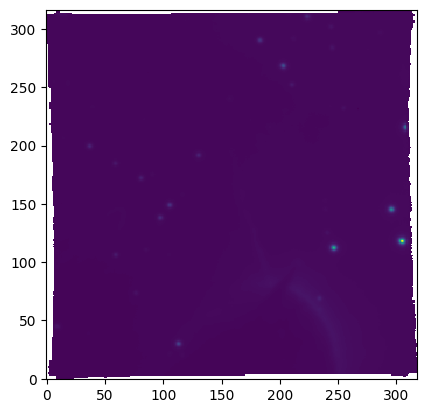

In [2]:
#White light image

white = cube.sum(axis=0)
white.plot()

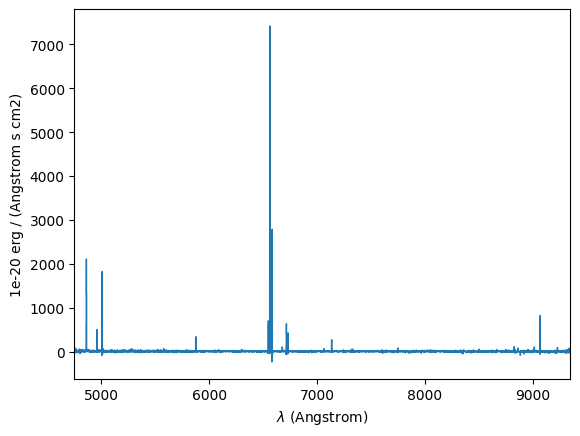

In [3]:
spec = cube[:, 150, 150]
spec.plot()

In [4]:
cube.wave.get_range()

array([4749.9921875, 9349.9921875])

In [5]:
from mpdaf.sdetect import SourceCatalog

white = cube.sum(axis=0)
cat = SourceCatalog(white, threshold=5)   # 5σ detection
cat.plot()


ImportError: cannot import name 'SourceCatalog' from 'mpdaf.sdetect' (C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\sdetect\__init__.py)

In [6]:
import mpdaf
print(mpdaf.__version__)


3.6


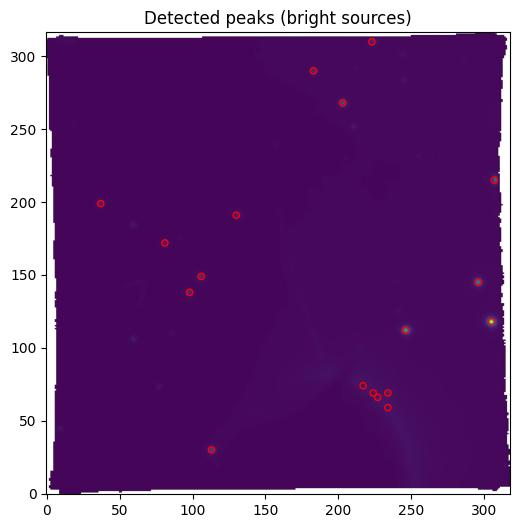

In [9]:
import numpy as np
from scipy.ndimage import maximum_filter, gaussian_filter
import matplotlib.pyplot as plt

white = cube.sum(axis=0)
data = white.data

# Smooth image to reduce noise
smooth = gaussian_filter(data, sigma=1)

# Find local maxima
neighborhood = maximum_filter(smooth, size=5)
peaks = (smooth == neighborhood) & (smooth > np.percentile(smooth, 99.5))

y, x = np.where(peaks)

plt.figure(figsize=(6,6))
plt.imshow(data, origin='lower', cmap='viridis')
plt.scatter(x, y, s=20, edgecolor='red', facecolor='none')
plt.title("Detected peaks (bright sources)")
plt.show()




In [10]:
spectra = []

for xi, yi in zip(x, y):
    spec = cube[:, yi, xi]
    spectra.append((xi, yi, spec))


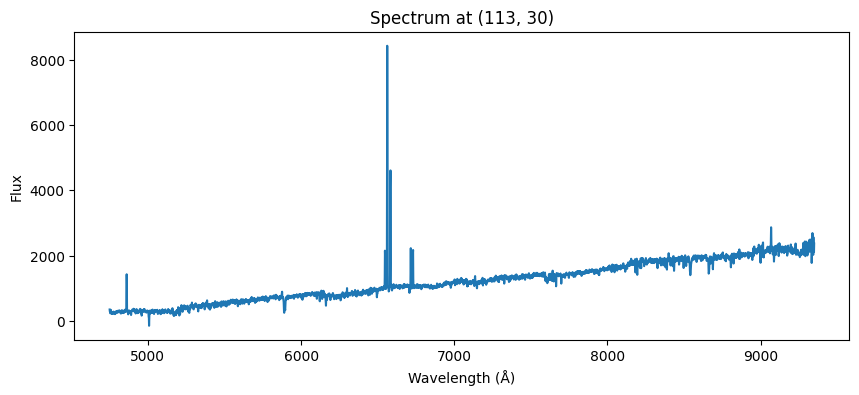

In [13]:
# Convert WaveCoord → numpy array
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title(f"Spectrum at ({xi}, {yi})")
plt.show()




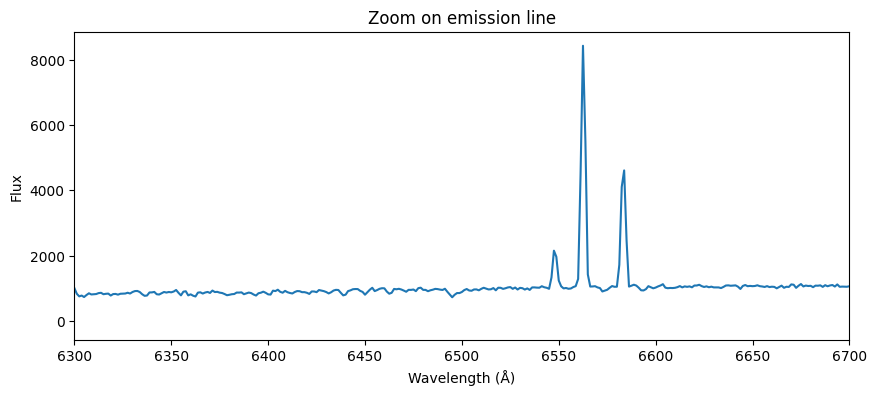

In [14]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlim(6300, 6700)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Zoom on emission line")
plt.show()


In [15]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(flux, height=np.percentile(flux, 99))
print(wave[peaks])


[6562.4921875 6583.7421875 9016.2421875 9068.7421875 9112.4921875
 9122.4921875 9124.9921875 9197.4921875 9228.7421875 9278.7421875
 9288.7421875 9297.4921875 9299.9921875 9313.7421875 9316.2421875
 9318.7421875 9321.2421875 9323.7421875 9327.4921875 9338.7421875
 9341.2421875 9344.9921875]


C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\obj\objs.py:211: RuntimeWarning: invalid value encountered in cast
  c = np.where(iseven, np.floor(center), np.floor(center + 0.5)).astype(int)
[WARNING] The world coordinates and data have different dimensions. Modifying the shape of the WCS object
C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\obj\cube.py:1882: RuntimeWarning: overflow encountered in scalar subtract
  shape = (sl.stop - sl.start, uy.stop - uy.start, ux.stop - ux.start)
[INFO] 225 spaxels used


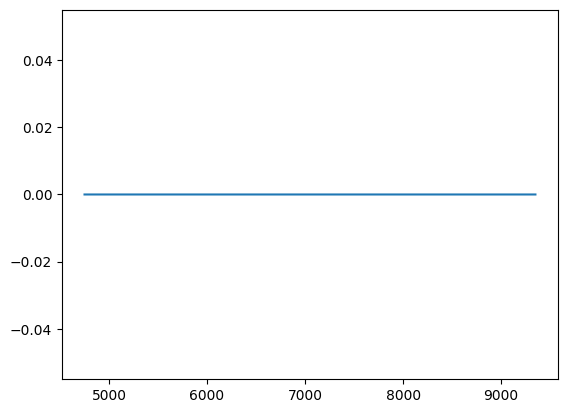

In [16]:
spec_ap = cube.aperture((yi, xi), radius=1.5)  # radius in pixels
wave = spec_ap.wave.coord(pixel=np.arange(spec_ap.shape[0]))
flux = spec_ap.data.filled(0)

plt.plot(wave, flux)


In [18]:
from scipy.signal import find_peaks
import numpy as np

peaks, props = find_peaks(flux, height=np.max(flux)*0.3)  # 30% of max
print("Peak wavelengths:", wave[peaks])
print("Peak heights:", props["peak_heights"])


Peak wavelengths: []
Peak heights: []


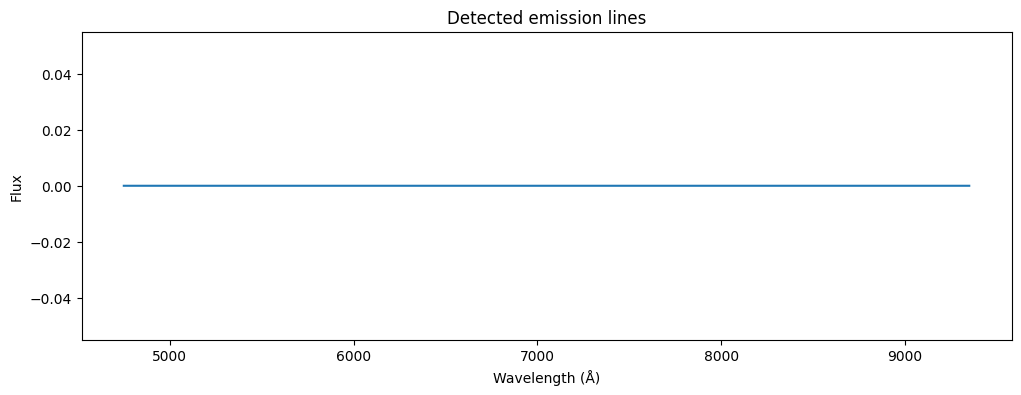

In [19]:
plt.figure(figsize=(12,4))
plt.plot(wave, flux)
plt.scatter(wave[peaks], flux[peaks], color='red', s=50)
plt.title("Detected emission lines")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.show()


In [20]:
print(flux.min(), flux.max())


0.0 0.0


In [21]:
print(flux.min(), flux.max())



0.0 0.0


In [22]:
print(spec.data.min(), spec.data.max())


-153.9138946533203 8433.5966796875


In [23]:
import numpy as np

idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 4749.9921875


In [24]:
xi, yi = 115, 50   # or whichever bright pixel you used

spec = cube[:, yi, xi]
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

print(flux.min(), flux.max())


-108.52461242675781 8787.279296875


In [25]:
idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 6562.4921875
